# Create an Image Embedding with GenBio-PathFM

This notebook takes one small H&E tissue image (a patch) and turns it into a list of 4,608 numbers called an **embedding**. The pretrained GenBio-PathFM model creates this representation from visual patterns in the image.

This is a feature-extraction demonstration. It does not predict gene expression or run PCA. You will load one patch, prepare it in the format the model expects, and inspect the resulting embedding.

## Before You Start

You need a downloaded HEST sample and internet access so the pretrained model can be downloaded the first time it is used. If you do not already have a patch, open [`preview_one_hest_sample.ipynb`](preview_one_hest_sample.ipynb) and complete **Steps 1–3**: sign in to Hugging Face, choose a sample ID, and download the sample. Step 3 saves its image patches to `data/patches/<sample_id>.h5`.

Use the same sample ID in the settings cell below. The code reads one patch from that file, so you do not need to download or prepare a separate PNG image. Downloaded data and model weights are large; do not commit them to Git.

## Install PyTorch for Your Computer

Install PyTorch in the same Python environment selected by this notebook's kernel. Choose one option, then restart the kernel before continuing. These commands install PyTorch and torchvision; install the rest of the project dependencies from `requirements.txt` if they are not already available.

### Windows or Linux with an NVIDIA GPU

First, open Command Prompt or a terminal and run:

```powershell
nvidia-smi
```

This should show your NVIDIA GPU and driver. The `CUDA Version` shown by `nvidia-smi` is the highest CUDA version supported by that driver; it does not necessarily mean the CUDA Toolkit is installed separately. If the command is missing or no GPU is listed, check the NVIDIA driver (ask your system administrator if needed), or use the CPU option.

Install the CUDA 13.0 PyTorch build used by this project:

In [5]:
%pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu130

Note: you may need to restart the kernel to use updated packages.


### Apple Silicon (M-series Mac) or no GPU

CUDA does not work on mac GPU, and  on a mac the attempt to download pytorch with `cu130` will be rejected. Thus, for mac, download the default pytorch, and Mac's GPU can be used just fine. It is also compatible with no GPU (falling back on CPU for computation).

*Note*: if you are on CPU, use just one patch as this notebook does; running the model will be slower.

In [4]:
%pip install -q torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Picking the best device to run on
import torch

cuda_available = torch.cuda.is_available()
mps_available = (
    hasattr(torch.backends, "mps")  # check if mps attribute even exists for safety
    and torch.backends.mps.is_available()
)

if cuda_available:
    device = torch.device("cuda")
elif mps_available:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("CUDA available:", cuda_available)
print("Apple Silicon GPU (MPS) available:", mps_available)
print("Using:", device)

CUDA available: True
Apple Silicon GPU (MPS) available: False
Using: cuda


## Load the Pretrained Model

This downloads GenBio-PathFM from Hugging Face the first time it runs, which can take a while. The model is placed on the available device selected above: NVIDIA GPU (`cuda`), Apple Silicon GPU (`mps`), or CPU.

In [11]:
from transformers import AutoModel

model = AutoModel.from_pretrained(
    "genbio-ai/genbio-pathfm",
    trust_remote_code=True,
)
model = model.to(device)
model.eval()

GenBioPathFMModel(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(1, 1536, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (rope_embed): RopePositionEmbedding()
    (blocks): ModuleList(
      (0-39): 40 x SelfAttentionBlock(
        (norm1): LayerNorm((1536,), eps=1e-06, elementwise_affine=True, bias=True)
        (attn): SelfAttention(
          (qkv): Linear(in_features=1536, out_features=4608, bias=False)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=1536, out_features=1536, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (norm2): LayerNorm((1536,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): SwiGLUFFN(
          (w1): Linear(in_features=1536, out_features=4096, bias=True)
          (w2): Linear(in_features=1536, out_features=4096, bias=True)
          (w3): Linear(in_features=4096, out_features=1

## Prepare the Image

The model expects a 224 × 224 color image. These steps resize the patch, convert its pixels to numbers, and normalize the color values using the model's expected averages and scales.

In [12]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.697, 0.575, 0.728),
        std=(0.188, 0.240, 0.187),
    ),
])

## Choose One Downloaded Patch

Set `sample_id` to the ID you downloaded in Step 3 of the preview notebook. `spot_index` chooses one patch from that sample; `0` means the first patch. HEST stores the image patches under the HDF5 key `img`.

In [3]:
from pathlib import Path

import h5py
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

sample_id = "TENX95"  # Change this to the sample ID you downloaded
data_dir = "data"  # the local directory where you downloaded the data
spot_index = 0
patch_filename = f"{sample_id}.h5"
patch_path_options = [
    Path(f"../{data_dir}/patches") / patch_filename,  # Notebook opened from notebooks/
    Path(f"{data_dir}/patches") / patch_filename,  # Notebook opened from the project root
]
patch_path = next((path for path in patch_path_options if path.exists()), None)

if patch_path is None:
    expected_paths = ", ".join(str(path) for path in patch_path_options)
    raise FileNotFoundError(
        f"Could not find {patch_filename}. Complete Steps 1-3 in "
        f"preview_one_hest_sample.ipynb, then check: {expected_paths}"
    )

with h5py.File(patch_path, "r") as patch_file:
    if "img" not in patch_file:
        raise KeyError(f"No 'img' dataset found in {patch_path}")
    image_count = patch_file["img"].shape[0]
    if not 0 <= spot_index < image_count:
        raise IndexError(
            f"spot_index {spot_index} is out of range; this sample has {image_count} patches"
        )
    patch_array = patch_file["img"][spot_index]

if patch_array.ndim != 3 or patch_array.shape[-1] not in (3, 4):
    raise ValueError(
        f"Expected a color patch with shape (height, width, channels); got {patch_array.shape}"
    )

image = Image.fromarray(np.asarray(patch_array, dtype=np.uint8)).convert("RGB")
print("Patch file:", patch_path)
print("Patch size:", image.size)

Patch file: ..\data\patches\TENX95.h5
Patch size: (224, 224)


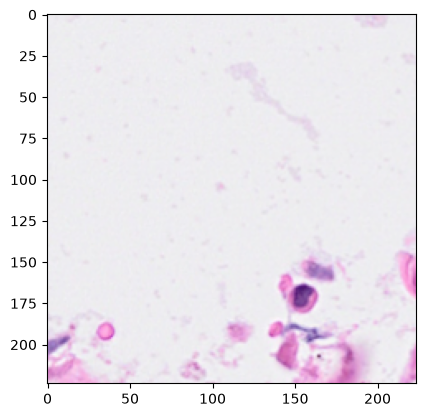

In [ ]:
plt.imshow(image)
plt.show()

## Create the Embedding

The transform turns the patch into a batch containing one image. The model returns one 4,608-number embedding for that image. The shape should be `(1, 4608)`: one patch and 4,608 learned visual measurements.

In [19]:
image_tensor = transform(image).unsqueeze(0).to(device)
print("Input tensor shape:", tuple(image_tensor.shape))

with torch.inference_mode():
    embedding = model(image_tensor)

print("Embedding shape:", tuple(embedding.shape))

Input tensor shape: (1, 3, 224, 224)
Embedding shape: (1, 4608)


## Inspect the Result

Each embedding number is a learned visual feature; the values do not correspond to named genes. Here are the first ten values as an example. The full tensor remains available as `embedding` for later analysis.

In [20]:
print(embedding)

tensor([[ 0.0473, -0.2399, -0.3706,  ...,  0.3129,  0.0947,  0.2943]],
       device='cuda:0')


Result is tensor. We remove the tensor from computation graph if the tensor has `requires_grad=True`. cpu moves from gpu to cpu. numpy converts to np array

In [21]:
print(embedding[0, -10:].detach().cpu().numpy())

[ 0.73115903 -0.22668996 -0.28592834 -0.95904243 -0.45355317 -0.90781784
 -0.43984184  0.31294385  0.09469599  0.2943432 ]
